<a href="https://www.kaggle.com/code/samratrm/cramers-v-and-synthetic-data-investigation?scriptVersionId=339526344" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

### Section Introduction: Categorical Association & Synthetic Data Investigation

**Overview**

* **Chi-square ($\chi^2$) & Cramér's V:** Learn how to measure categorical independence using the $\chi^2$ test statistic and quantify association strength using Cramér's V effect size.
* **Student Health Data Application:** Implement these statistical techniques on a 50k-row student health behavior dataset (`SHR`) to identify and rank feature associations.
* **Synthetic Data Investigation:** Leverage strong Cramér's V signals to investigate potential data leakage and reverse-engineer underlying synthetic generation rules.

## Part 1 — Chi-Square: Measuring Independence

**Core Objective**

* Determines whether two categorical variables are statistically associated or independent (answers *does knowing one variable provide information about the other?*).

**Toy Example Setup**

* Imagine a sample of $100$ students with two categorical variables: `smokes` (`yes`/`no`) and `sleep_quality` (`poor`/`good`).
* **Contingency table:** A frequency grid counting joint occurrences of two categorical variables:

|  | `poor` | `good` | Total |
| --- | --- | --- | --- |
| **`smokes = yes`** | $30$ | $10$ | **$40$** |
| **`smokes = no`** | $20$ | $40$ | **$60$** |
| **Total** | **$50$** | **$50$** | **$100$** |

**The Expected Baseline**

* **Under independence:** The distribution of cell counts should reflect overall row and column proportions without dependence between variables.
* **Expected frequency formula:**

$$\text{Expected} = \frac{\text{Row Total} \times \text{Col Total}}{N}$$


* **Calculated expected counts:**
* `smokes = yes` & `poor`: $\frac{40 \times 50}{100} = \mathbf{20}$ (Observed: $30$)
* `smokes = yes` & `good`: $\frac{40 \times 50}{100} = \mathbf{20}$ (Observed: $10$)
* `smokes = no` & `poor`: $\frac{60 \times 50}{100} = \mathbf{30}$ (Observed: $20$)
* `smokes = no` & `good`: $\frac{60 \times 50}{100} = \mathbf{30}$ (Observed: $40$)



**The Chi-Square ($\chi^2$) Statistic**

* **Calculation:** Sums the normalized squared differences across all cells:

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$


* **Example calculation:**

$$\chi^2 = \frac{(30 - 20)^2}{20} + \frac{(10 - 20)^2}{20} + \frac{(20 - 30)^2}{30} + \frac{(40 - 30)^2}{30} = 5 + 5 + 3.33 + 3.33 = \mathbf{16.67}$$


* **Interpretation:** $\chi^2 = 0$ indicates complete independence. Larger $\chi^2$ values signal stronger departures from expected baseline counts.

**Degrees of Freedom ($df$)**

* **Formula:**

$$df = (r - 1)(c - 1)$$



For a $2 \times 2$ table: $(2 - 1)(2 - 1) = \mathbf{1}$.
* **Intuition:** The number of cell counts free to vary independently once row and column marginal totals are fixed.

**The Limit of $p$-Values at Scale**

* **$p$-value meaning:** The probability of observing a $\chi^2$ statistic this extreme purely by random sampling under independence.
* **Sample size sensitivity:** As $N$ grows large ($N = 50,000$), $p$-values rapidly collapse to near zero ($p \approx 0$) for nearly all features, making them uninformative for ranking feature importance.

### Test Statistic vs. Effect Size

**Core Concept**

* **Test statistic ($\chi^2$):** Determines whether an association exists between categorical variables (answers *is it real?*).
* **Effect size (Cramér's V):** Measures the magnitude or strength of that association (answers *does it matter?*).

**The Problem with $\chi^2$**

* **Inflated scale:** $\chi^2 \in [0, \infty)$ grows with sample size ($N$) and table dimension ($(r-1)(c-1)$), making raw values uninterpretable on their own.
* **Non-comparable:** A large $\chi^2$ can indicate a strong relationship or simply a large dataset with many categories.
* **Uninformative $p$-values at scale:** At large sample sizes ($N = 50,000$), $p$-values drive to near zero for virtually all features, signaling presence but failing to differentiate strength.

**The Solution with Cramér's V**

* **Formula:**

$$V = \sqrt{\frac{\chi^2}{N \cdot (k - 1)}}$$



where $k = \min(\text{rows}, \text{cols})$ and $N$ is total sample size.
* **Bounded range:** Normalizes values strictly onto $V \in [0, 1]$, making results directly comparable across different dataset sizes and table shapes.
* **Benchmark bands:**
* $\approx 0.1$: Weak association
* $\approx 0.3$: Moderate association
* $\ge 0.5$: Strong association



**Key Terms**

* **Observed vs. expected:** Actual cell frequencies vs. calculated frequencies under the assumption of complete independence:

$$\text{Expected} = \frac{\text{Row Total} \times \text{Col Total}}{N}$$


* **Degrees of freedom:** $(r - 1)(c - 1)$, representing the number of independent cells in the contingency table.

**Modeling Context**

* Just as $\eta^2$ was used over raw ANOVA $F$-statistics for numerical features, Cramér's V serves as the necessary metric to reliably rank categorical feature associations at scale.

## Part 2 — Cramér's V: Measuring Association Strength

**The Problem with Chi-Square**

* **Sample size dependence ($N$):** $\chi^2$ scales directly with dataset size. The same relative proportion on $10,000$ rows yields a $100\times$ larger $\chi^2$ than on $100$ rows.
* **Table size dependence:** Larger contingency tables contain more cells, adding more $\frac{(O - E)^2}{E}$ terms and inflating $\chi^2$ strictly due to dimensions.
* **Unbounded scale:** $\chi^2 \in [0, \infty)$ cannot be compared across different features or dataset sizes.

**The Solution: Cramér's V**

* **Formula:**

$$V = \sqrt{\frac{\chi^2}{N \cdot (k - 1)}}$$



where $k = \min(\text{rows}, \text{cols})$ and $N$ is total sample size.
* **Normalization mechanism:**
* Dividing by $N$ removes sample size inflation.
* Dividing by $(k - 1)$ removes table dimension inflation.
* Square root maps the result onto a standardized scale $V \in [0, 1]$.



**Interpretation Guidelines**

* **Scale range:** $0$ indicates total independence, $1$ indicates perfect determination.
* **Standard benchmark bands:**
* $\approx 0.1$: Weak association
* $\approx 0.3$: Moderate association
* $\ge 0.5$: Strong association



**Key Takeaways**

* $\chi^2$ is a **test statistic** (signals if association exists), while Cramér's V is an **effect size** (measures how strong it is).
* Cramér's V allows direct, apples-to-apples comparison of categorical feature relationships across datasets of any size.

---

# Scratch Code Example

In [1]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/student_health_dataset_50k.csv")
df.head()

,student_id,timestamp,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,health_condition
0,1102,2025-01-01 00:00:00,9.29,67.4,28.56,2113.0,5227,91.3,2.08,veg,high,average,active,yes,other,at-risk
1,1435,2025-01-01 01:00:00,9.33,57.2,30.17,2060.0,14460,67.0,2.57,veg,medium,average,active,occasional,male,at-risk
2,1860,2025-01-01 02:00:00,8.33,73.7,19.93,2236.0,14589,52.6,1.93,non-veg,high,average,active,no,other,at-risk
3,1270,2025-01-01 03:00:00,5.60,61.9,22.02,2650.0,12618,55.2,2.97,veg,high,average,active,no,other,unhealthy
4,1106,2025-01-01 04:00:00,9.10,69.6,20.85,1985.0,14518,27.1,3.09,non-veg,medium,poor,sedentary,occasional,male,at-risk


In [3]:
df.drop("timestamp",axis=1, inplace=True)

In [4]:
cat_cols = df.select_dtypes("object").columns.to_list()
cat_cols

['diet_type',
 'stress_level',
 'sleep_quality',
 'physical_activity_level',
 'smoking_alcohol',
 'gender',
 'health_condition']

In [5]:
from scipy.stats import chi2_contingency

def calc_cramerV(tab, feat1, feat2):
    ct = pd.crosstab(
            tab[feat1],
            tab[feat2],
            margins=True,
            margins_name="Total"
        )
        
    c2 = chi2_contingency(ct)
    
    k = max(c2.expected_freq.shape)
    N = ct["Total"]["Total"]
    
    cv = np.sqrt( c2.statistic / N*(k-1) )
    return cv

result = []
for i in range(len(cat_cols)):
    for j in range(i):
        cv = calc_cramerV(df, cat_cols[i], cat_cols[j])
        result.append({
            "Feature 1": cat_cols[i],
            "Feature 2": cat_cols[j],
            "Cramers_V": cv
        })
results_df = pd.DataFrame(result).sort_values(by="Cramers_V", ascending=False)
print(results_df)

                  Feature 1                Feature 2  Cramers_V
16         health_condition             stress_level   0.962793
18         health_condition  physical_activity_level   0.561464
15         health_condition                diet_type   0.028474
10                   gender                diet_type   0.027095
5   physical_activity_level            sleep_quality   0.026102
2             sleep_quality             stress_level   0.025310
20         health_condition                   gender   0.023518
17         health_condition            sleep_quality   0.021683
3   physical_activity_level                diet_type   0.021165
19         health_condition          smoking_alcohol   0.018246
6           smoking_alcohol                diet_type   0.018158
11                   gender             stress_level   0.018105
9           smoking_alcohol  physical_activity_level   0.016181
14                   gender          smoking_alcohol   0.016039
13                   gender  physical_ac

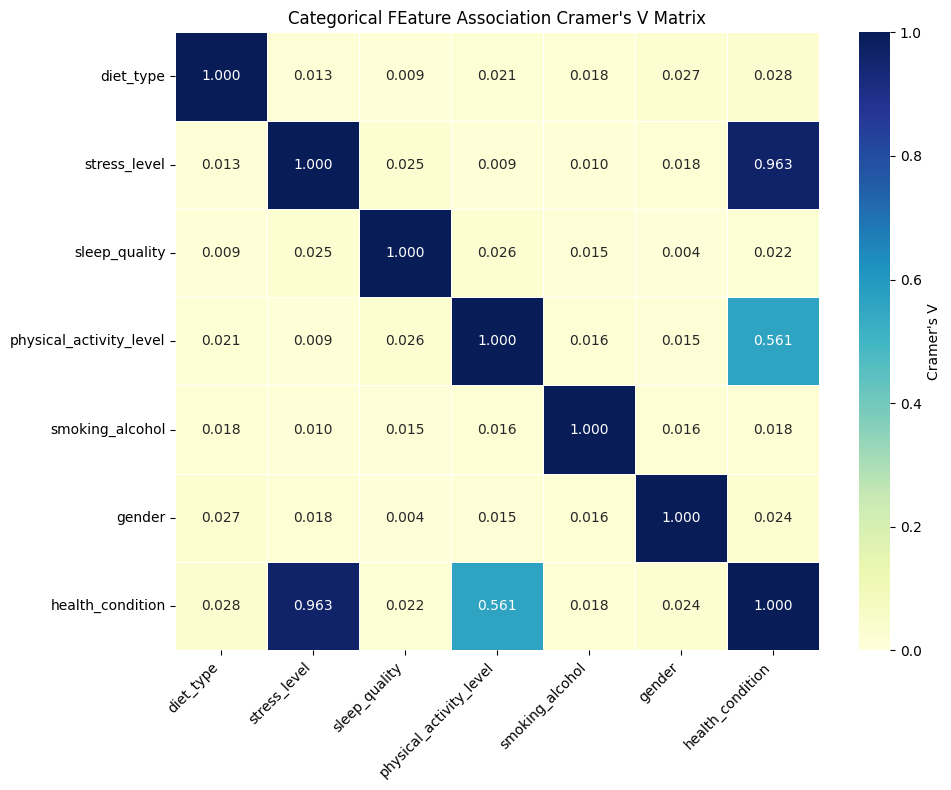

In [6]:
cramer_matrix = pd.DataFrame(1.0, index=cat_cols, columns=cat_cols)

for _, row in results_df.iterrows():
    f1, f2, val = row["Feature 1"] , row["Feature 2"] , row["Cramers_V"]
    cramer_matrix.loc[f1,f2] = val
    cramer_matrix.loc[f2,f1] = val

plt.figure(figsize=(10,8))
sns.heatmap(
    data=cramer_matrix,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label":"Cramer's V"}
)

plt.title("Categorical FEature Association Cramer's V Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Key Takeaways

1. **`stress_level` & `health_condition` ($V \approx 0.963$):**
* **Near-perfect association.** In practical predictive modeling, a value this high is often a red flag for **data leakage** or an artificially synthetic rule (e.g., if `health_condition` was directly computed/labeled using `stress_level` thresholds during dataset generation).

2. **`physical_activity_level` & `health_condition` ($V \approx 0.561$):**
* **Strong, meaningful relationship.** Physical activity is a strong predictor of health status in this dataset without being totally redundant.

3. **All Other Pairwise Combinations ($V < 0.03$):**
* **Nearly independent.** Features like `gender`, `diet_type`, `smoking_alcohol`, and `sleep_quality` share almost zero categorical mutual association with one another.

---

# Synthetic Data Investigation Overview

**Motivation**

* Pairwise Cramér's V analysis revealed strong associations between `health_condition` and both `stress_level` ($V \approx 0.963$) and `physical_activity_level` ($V \approx 0.561$).
* All other categorical features showed negligible association ($V < 0.03$), indicating that `health_condition` is almost entirely driven by these two variables.

**Objective**

* Investigate whether `health_condition` was generated synthetically using programmatic conditional rules based on `stress_level` and `physical_activity_level`.
* Evaluate the deterministic boundaries and probabilistic splits using cross-tabulations and a simple Decision Tree classifier to detect potential data leakage.

In [7]:
# Detailed counts across stress_level and physical_activity_level
health_breakdown = pd.crosstab(
    index=[df['stress_level'], df['physical_activity_level']], 
    columns=df['health_condition'],
    margins=True
)

print("--- Counts ---")
display(health_breakdown)

--- Counts ---


health_condition                      at-risk   fit  unhealthy    All
stress_level physical_activity_level                                 
high         active                      3654     0       1302   4956
             moderate                    3799     0       1279   5078
             sedentary                   3715     0       1235   4950
low          active                      2473  2466          0   4939
             moderate                    4964     0          0   4964
             sedentary                   4917     0          0   4917
medium       active                      6708     0          0   6708
             moderate                    6733     0          0   6733
             sedentary                   6755     0          0   6755
All                                     43718  2466       3816  50000

In [8]:
# Percentage breakdown per stress & activity combination
health_pct = pd.crosstab(
    index=[df['stress_level'], df['physical_activity_level']], 
    columns=df['health_condition'],
    normalize='index'
) * 100

print("\n--- Percentages (%) ---")
display(health_pct.round(2))


--- Percentages (%) ---


health_condition                      at-risk    fit  unhealthy
stress_level physical_activity_level                           
high         active                     73.73   0.00      26.27
             moderate                   74.81   0.00      25.19
             sedentary                  75.05   0.00      24.95
low          active                     50.07  49.93       0.00
             moderate                  100.00   0.00       0.00
             sedentary                 100.00   0.00       0.00
medium       active                    100.00   0.00       0.00
             moderate                  100.00   0.00       0.00
             sedentary                 100.00   0.00       0.00

### Crosstab Interpretation

**How to Read the Table**

* Each row shows the row-wise percentage distribution of `health_condition` for combinations of `stress_level` and `physical_activity_level` (summing to 100%).

**Key Findings**

* **Medium stress:** 100% of students with `medium` `stress_level` are labeled `at-risk` across all activity levels. `fit` and `unhealthy` never appear here.
* **Low stress:** `fit` only occurs when `stress_level` is `low` and `physical_activity_level` is `active` (~49.93%). `low` stress with `moderate` or `sedentary` activity results in 100% `at-risk`.
* **High stress:** `unhealthy` only occurs when `stress_level` is `high` (~25% `unhealthy`, ~75% `at-risk`), regardless of activity level.

**Data Generation Rule**

* `health_condition` was synthetically assigned using strict conditional logic:
* `medium` `stress_level` $\rightarrow$ 100% `at-risk`
* `low` `stress_level` + `active` `physical_activity_level` $\rightarrow$ ~50% `fit`, ~50% `at-risk`
* `low` `stress_level` + `moderate`/`sedentary` $\rightarrow$ 100% `at-risk`
* `high` `stress_level` $\rightarrow$ ~25% `unhealthy`, ~75% `at-risk`



**Modeling Impact**

* `health_condition` is almost completely derived from `stress_level` and `physical_activity_level`, creating potential data leakage if used together in predictive models.

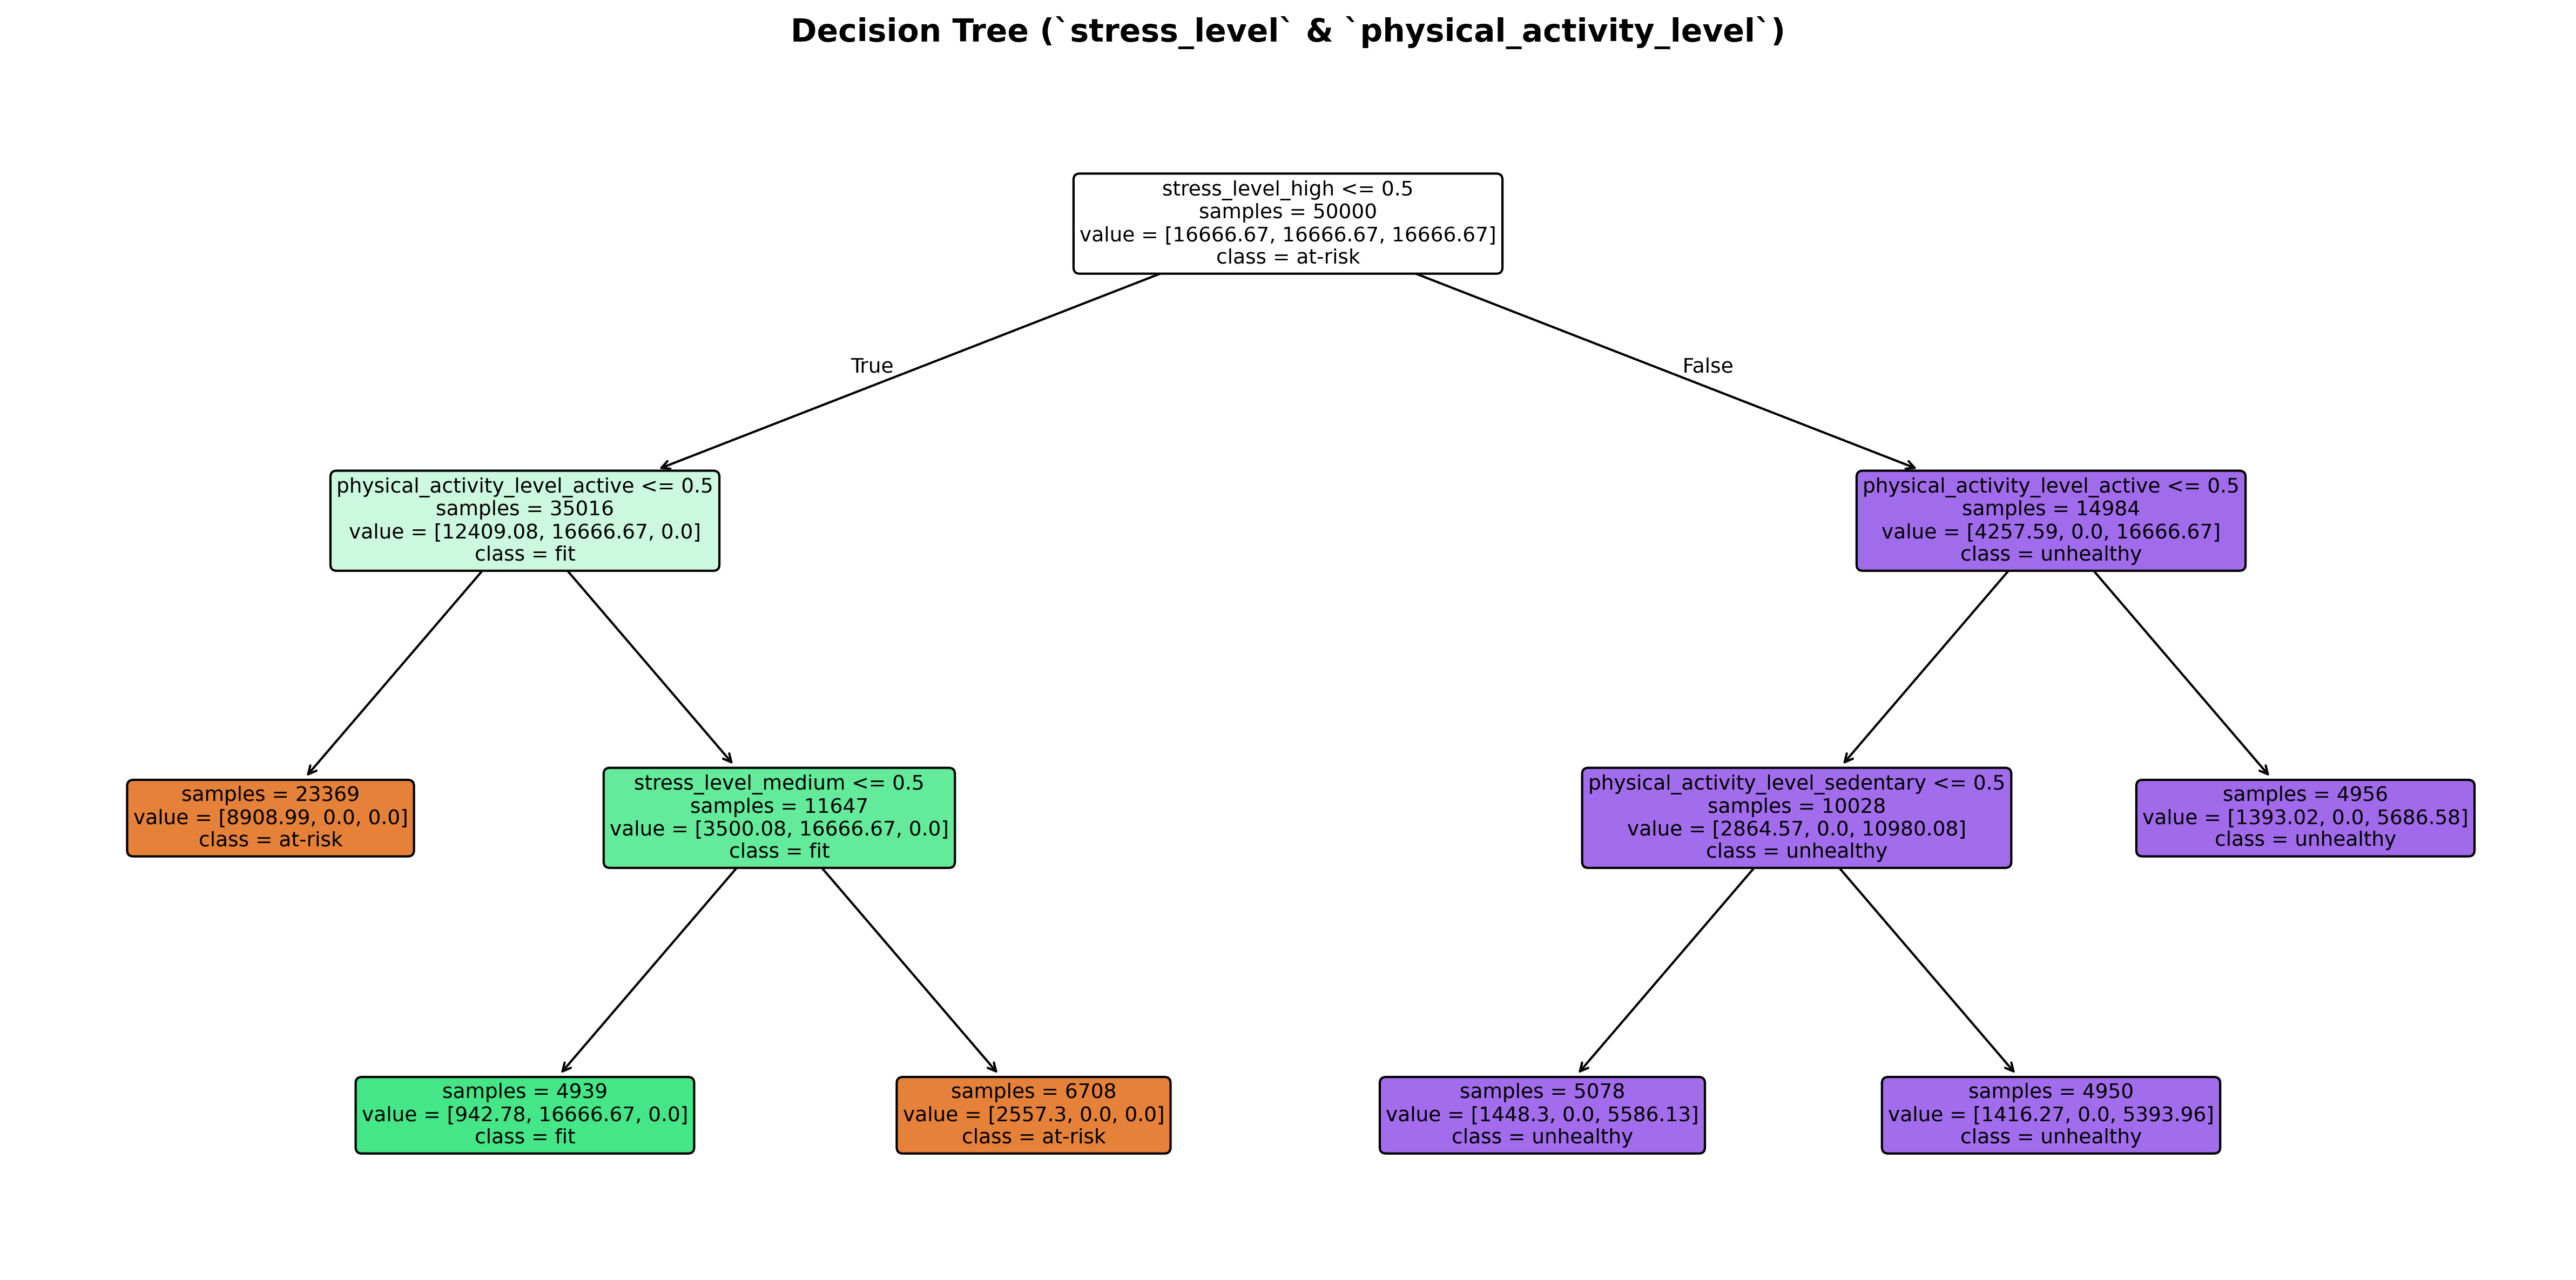

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# One-hot encode the two strong features
X = pd.get_dummies(df[['stress_level', 'physical_activity_level']], drop_first=False)
y = df['health_condition']

# Train a simple decision tree
dt = DecisionTreeClassifier(max_depth=5,class_weight='balanced')
dt.fit(X, y)

plt.figure(figsize=(16, 8), dpi=300)
plot_tree(
    dt,
    feature_names=list(X.columns),
    class_names=list(dt.classes_),
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=False,
    precision=2,
)

plt.title("Decision Tree (`stress_level` & `physical_activity_level`)",
         fontsize=14,
         pad=15,
         weight="bold"
         )
plt.tight_layout()
plt.show()

In [10]:
accuracy = dt.score(X, y)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7272


--- Classification Report ---
              precision    recall  f1-score   support

     at-risk       1.00      0.69      0.82     43718
         fit       0.50      1.00      0.67      2466
   unhealthy       0.25      1.00      0.41      3816

    accuracy                           0.73     50000
   macro avg       0.58      0.90      0.63     50000
weighted avg       0.92      0.73      0.78     50000


--- Confusion Matrix ---


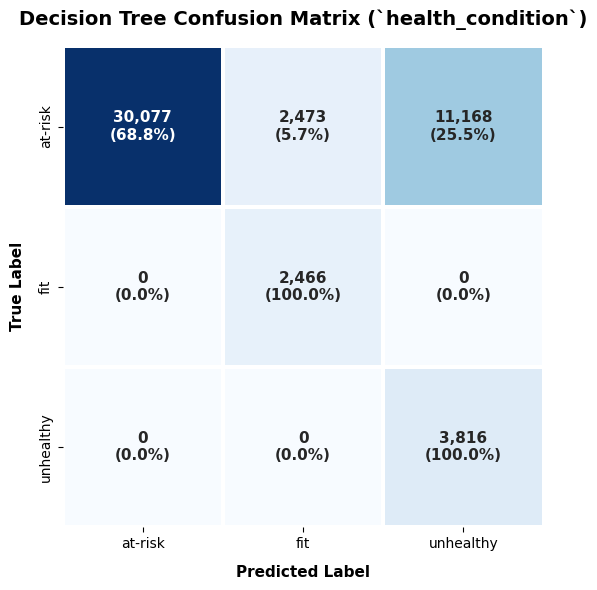

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = dt.predict(X)

print("--- Classification Report ---")
print(classification_report(y, y_pred))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y, y_pred)
classes = dt.classes_

cm_pct = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

# Create combined annotations: Count + (Percentage%)
annot_labels = [
    [f"{count:,}\n({pct:.1f}%)" for count, pct in zip(row_counts, row_pcts)]
    for row_counts, row_pcts in zip(cm, cm_pct)
]

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=annot_labels,
    fmt="",  # Pre-formatted string annotations
    cmap="Blues",
    cbar=False,
    square=True,
    linewidths=1.5,
    xticklabels=classes,
    yticklabels=classes,
    annot_kws={"size": 11, "weight": "bold"},
)

plt.title(
    "Decision Tree Confusion Matrix (`health_condition`)",
    fontsize=14,
    pad=15,
    weight="bold",
)
plt.xlabel("Predicted Label", fontsize=11, weight="bold", labelpad=10)
plt.ylabel("True Label", fontsize=11, weight="bold", labelpad=10)

plt.tight_layout()
plt.show()

### Decision Tree and Confusion Matrix Interpretation

**Decision Tree Overview**

* **Features used:** Trained exclusively on `stress_level` and `physical_activity_level`.
* **Overall accuracy:** Reached ~72.7% accuracy with `class_weight='balanced'`.
* **Learned rules:** `medium` `stress_level` maps to `at-risk`, `fit` requires `low` `stress_level` and `active` `physical_activity_level`, and `unhealthy` requires `high` `stress_level`.

**Metrics and Confusion Matrix Breakdown**

* **Minority class recall:** Achieved 100% recall for both `fit` (2,466/2,466) and `unhealthy` (3,816/3,816) with zero false negatives.
* **Error distribution:** All 13,641 misclassifications came from true `at-risk` samples (2,473 predicted as `fit` and 11,168 predicted as `unhealthy`).
* **Category alarms:** True `fit` and `unhealthy` instances were never misclassified into any other class.
* **Precision trade-offs:** `at-risk` precision reached 1.00 (zero false positives), while `fit` precision was 0.50 and `unhealthy` precision was 0.25 due to `at-risk` overlap.

**Data Insights**

* **Hard boundaries:** `fit` and `unhealthy` labels follow strict threshold conditions.
* **Catch-all state:** `at-risk` serves as the baseline synthetic class, sharing feature space with both minority categories.

---

### Synthetic Data Investigation Summary

**Key Finding**

* `health_condition` was synthetically generated using a hardcoded conditional rule system based almost entirely on `stress_level` and `physical_activity_level`.

**Underlying Rules**

* **`medium` `stress_level`:** Maps to 100% `at-risk` (never produces `fit` or `unhealthy`).
* **`low` `stress_level` + `active` `physical_activity_level`:** Produces ~50% `fit` and ~50% `at-risk` (the only path to a `fit` label).
* **`low` `stress_level` + `moderate`/`sedentary`:** Maps to 100% `at-risk`.
* **`high` `stress_level`:** Produces ~25% `unhealthy` and ~75% `at-risk` (the only path to an `unhealthy` label).

**Proof from Output**

* **High Cramér's V:** `stress_level` and `health_condition` share an association score of ~0.963.
* **100% minority recall:** True `fit` and `unhealthy` samples achieved 1.00 recall with zero false negatives.
* **One-sided errors:** All misclassifications came exclusively from true `at-risk` samples spilling over into `fit` or `unhealthy` predictions.

**Modeling Takeaway**

* `health_condition` is virtually a re-labeled combination of `stress_level` and `physical_activity_level`, representing clear data leakage if used alongside them.